In [1]:
import sys 
sys.path.append("../../src/")
import TFIM_operators_from_states as operators
import numerical_quenches as nq
from project_imports import *

import general_projectors as gp

In [192]:
def P_vector(n,nhat,states):
    return array([gp.P_generic(n,nhat,state) for state in states])


def free_evo_states(tau, gf, g0, L):

    tf = tau*(1-gf)

    # ramp from 0 to tf
    t_eval_quench = np.linspace(0, tf, 2)
    args = (tau, tf)

    states_quench = nq.states(L, t_eval_quench,
                              nq.g_linear_hold, args)

    # free evolution continues in absolute time
    t_eval_free = np.linspace(tf, tf + 2*np.pi, 100)

    states_free = nq.states(L, t_eval_free,
                            nq.g_linear_hold, args,
                            states_quench[-1])

    return states_free, t_eval_free

def O_n(N,n,states):
    return array([gp.Small_Z_Expansion(N,state,n) for state in states])



In [224]:
free_states =[ ]
free_times = []
taus_free=  [.1,1,10,25]
g0=5
gf=0
L=300
for tau in taus_free:
    states,t_eval = free_evo_states(tau,gf,g0,L)
    free_states.append(states)
    free_times.append(t_eval)


import analytical_quench_states as kz
taus= np.logspace(-1.5,3,100)
psi_quench_states= [kz.state(100,tau,tau) for tau in taus]





g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0
g0=1.0
g0=0.0


# Expected Result:

In the limit of small theta

$$P_g = P^x ( 1- \theta^2/2) + 1/2^N (\theta O_1 - \theta^3 O_2/6)

[np.float64(0.9995065603657316), np.float64(0.03141075907812829)]

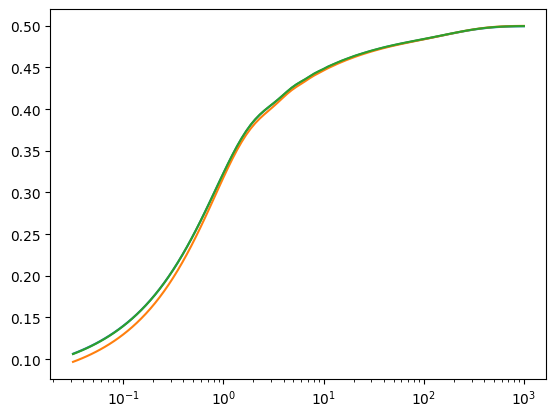

In [225]:
N = 4
P2 = P_vector(N,nhat,psi_quench_states)
P20 = P_vector(N,nhat0,psi_quench_states)
#Ansatz:

Pg = P20*(1-theta**2/2)+(1/2**N)*(theta* O_n(N,1,psi_quench_states))#-theta**3/6 *O_n(N,3,states))

plot(taus,P2)
plot(taus,P20)
plot(taus,Pg)
xscale("log")

show()


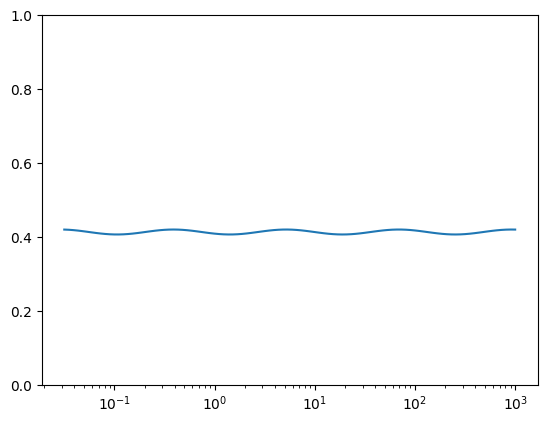

In [226]:


theta = pi/100
nhat0= [1,0]
nhat = [cos(theta),sin(theta)]
nhat

N = 2
P2 = P_vector(N,nhat,free_states[0])
P20 = P_vector(N,nhat0,free_states[0])
#Ansatz:

Pg = P20*(1-theta**2/2)+(1/2**N)*(theta* O_n(N,1,free_states[0]))#-theta**3/6 *O_n(N,3,states))

plot(taus,P2)
#plot(taus,P20)
#plot(taus,Pg)
xscale("log")
ylim(0,1)

show()


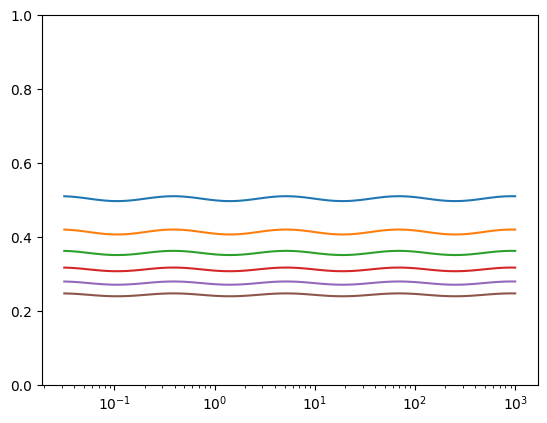

In [227]:
Ns = [1,2,3,4,5,6]
Pgs= []
for N in Ns:
    P2 = P_vector(N,nhat,free_states[0])
    P20 = P_vector(N,nhat0,free_states[0])
#Ansatz:

    Pg = P20*(1-theta**2/2)+(1/2**N)*(theta* O_n(N,1,free_states[0]))#-theta**3/6 *O_n(N,3,states))

    plot(taus,P2)
    Pgs.append(P2)
#plot(taus,P20)
#plot(taus,Pg)
    xscale("log")
    ylim(0,1)

show()


In [228]:
Ns = [1,2,3,4,5,6]
Pgs2= []
for N in Ns:
    P2 = P_vector(N,nhat,free_states[1])
    Pgs2.append(P2)

Ns = [1,2,3,4,5,6]
Pgs3= []
for N in Ns:
    P2 = P_vector(N,nhat,free_states[2])
    Pgs3.append(P2)


Ns = [1,2,3,4,5,6]
Pgs4= []
for N in Ns:
    P2 = P_vector(N,nhat,free_states[3])
    Pgs4.append(P2)

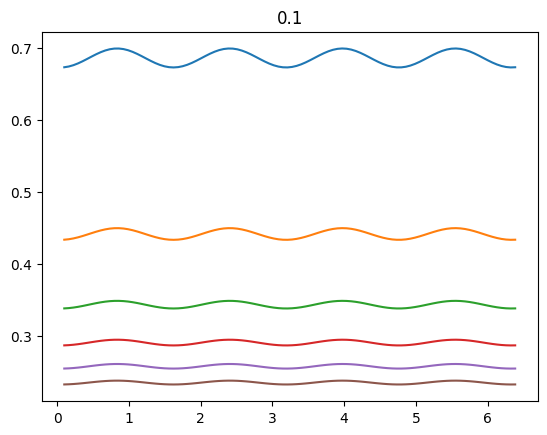

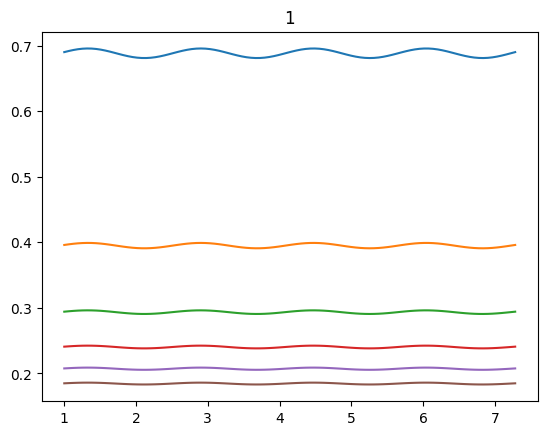

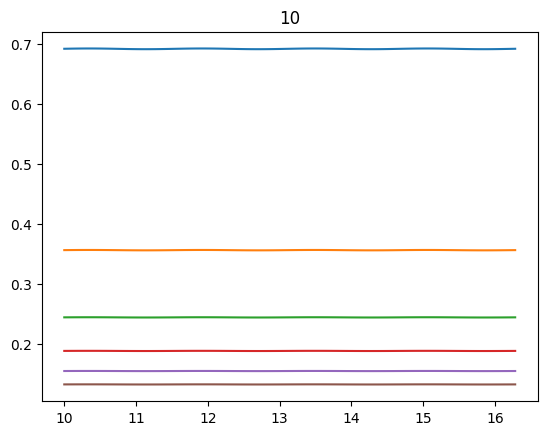

Text(0.5, 1.0, '25')

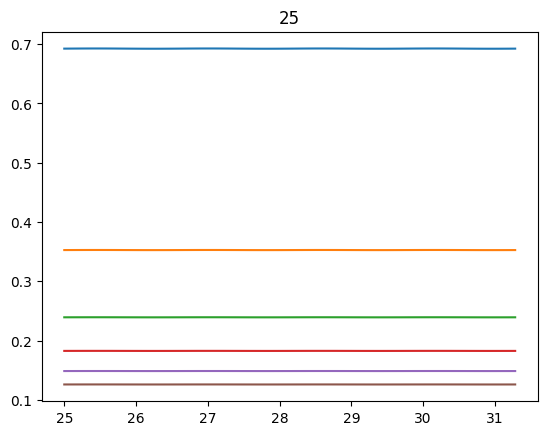

In [229]:
plot(free_times[0],-log(array(Pgs).T)/array(Ns))
title(taus_free[0])
show()
plot(free_times[1],-log(array(Pgs2).T)/array(Ns))
title(taus_free[1])

show()
plot(free_times[2],-log(array(Pgs3).T)/array(Ns))
title(taus_free[2])

show()
plot(free_times[3],-log(array(Pgs4).T)/array(Ns))
title(taus_free[3])



In [ ]:
N1n1 = N_n(1, 1, states)
N2n1 = N_n(2, 1, states)
N3n1 = N_n(3, 1, states)
N4n1 = N_n(4, 1, states)
N5n1 = N_n(5, 1, states)
N6n1 = N_n(6, 1, states)
N7n1 = N_n(7, 1, states)
N8n1 = N_n(8, 1, states)

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


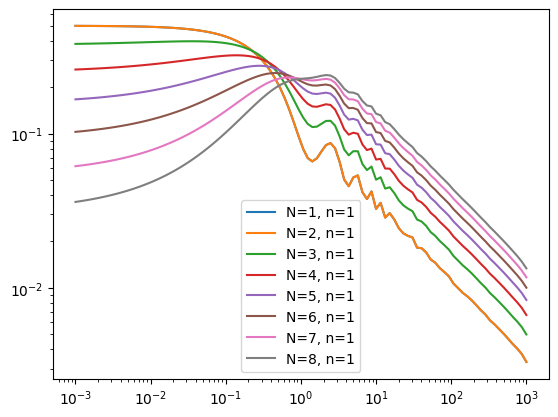

In [34]:
plot(taus,array(N1n1)/2,label="N=1, n=1")
plot(taus,N2n1/4,label="N=2, n=1")
plot(taus,N3n1/8,label="N=3, n=1")
plot(taus,N4n1/16,label="N=4, n=1")
plot(taus,N5n1/32,label="N=5, n=1")
plot(taus,N6n1/64,label="N=6, n=1")
plot(taus,N7n1/128,label="N=7, n=1")
plot(taus,N8n1/256,label="N=8, n=1")

loglog()
legend()
show()

# plot(taus,N6n1,label="N=8, n=1")
# plot(taus,N6n2,label="N=8, n=2")
# plot(taus,N6n3,label="N=8, n=3")
# plot(taus,N6n4,label="N=8, n=4")
# plot(taus,N6n8,label="N=8, n=8")

# legend()

# loglog()
# show()

In [16]:
Ns = range(2, 9)

results_n2 = {N: N_n(N, 2, states) for N in Ns}

/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


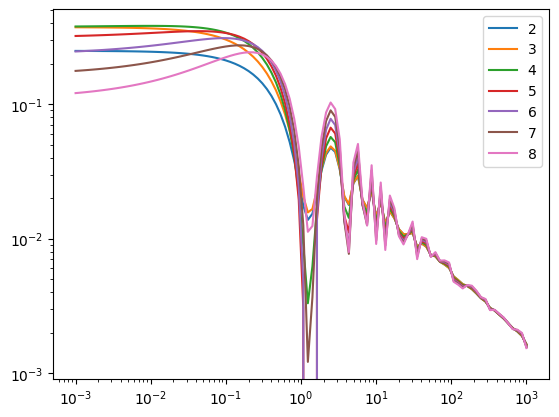

In [19]:
for n in Ns:
    plot(taus, results_n2[n]/2**n,label=n)
    loglog()
    legend()

[]

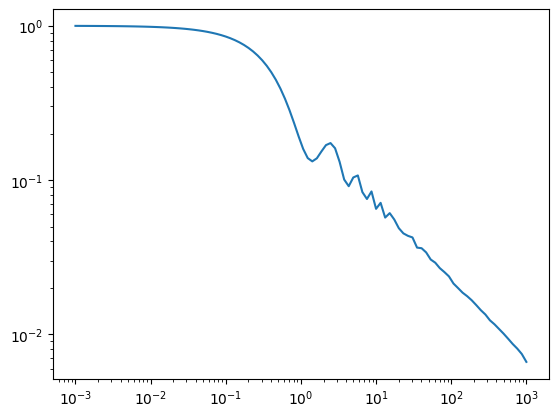

In [12]:
import TFIM_operators_from_states as op 

sz = [op.sz_correlation([0],s) for s in states]

plot(taus,sz)
loglog()

In [37]:
groundstate = nq.groundstate(0,100)
u,v,k = groundstate

states =[]
for j in range(len(k)):
    ut,vt = u.copy(), v.copy()

    ut[j] = v[j]
    vt[j] = u[j]

    state = [ut,vt,k]
    states.append(state)



In [39]:
N1n1 = N_n(1, 1, states)
N2n1 = N_n(2, 1, states)
N3n1 = N_n(3, 1, states)
N4n1 = N_n(4, 1, states)
N5n1 = N_n(5, 1, states)
N6n1 = N_n(6, 1, states)
N7n1 = N_n(7, 1, states)
N8n1 = N_n(8, 1, states)


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


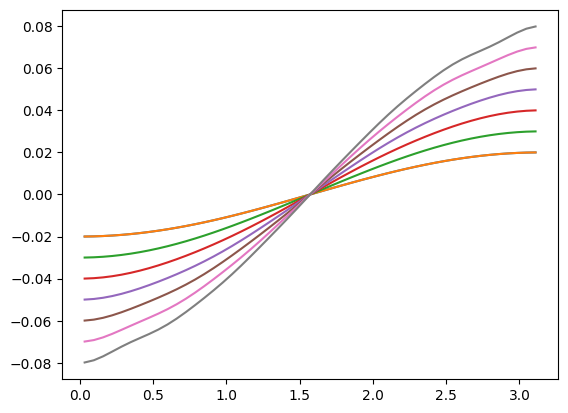

In [41]:
plot(k,N1n1/2)
plot(k,N2n1/4)
plot(k,N3n1/8)
plot(k,N4n1/2**4)
plot(k,N5n1/2**5)
plot(k,N6n1/2**6)
plot(k,N7n1/2**7)
plot(k,N8n1/2**8)

In [46]:
N2n1 = N_n(2, 2, states)
N3n1 = N_n(3, 2, states)
N4n1 = N_n(4, 2, states)
N5n1 = N_n(5, 2, states)
N6n1 = N_n(6, 2, states)
N7n1 = N_n(7, 2, states)
N8n1 = N_n(8, 2, states)
N9n1 = N_n(9, 2, states)


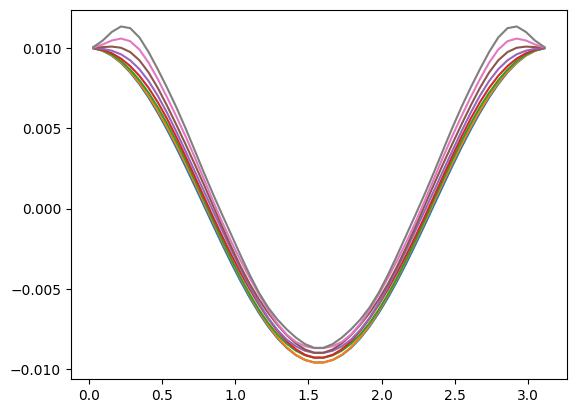

In [47]:
plot(k,N2n1/4)
plot(k,N3n1/8)
plot(k,N4n1/2**4)
plot(k,N5n1/2**5)
plot(k,N6n1/2**6)
plot(k,N7n1/2**7)
plot(k,N8n1/2**8)
plot(k,N9n1/2**9)